# ITM 454 - Natural Language Processing
## Text Classification: News Classification

---

### 1. Data Collection

No manual collection needed. We will use built-in sklearn datasets that already have labelled categories.

In [2]:
from sklearn.datasets import fetch_20newsgroups
import numpy as np

# Select 4 categories for simplicity
categories = [
    'comp.graphics',      # Technology
    'rec.sport.baseball', # Sports  
    'talk.politics.misc', # Politics
    'sci.space'          # Science
]

# Load training data
newsgroups_train = fetch_20newsgroups(
    subset='train', # The data is already splitted by sklearn so we can just select their train set
    categories=categories,
    shuffle=True,
    random_state=82,    # seed values because we shuffle the data, for reproducibility
    remove=('headers', 'footers', 'quotes')  # Clean the data
)

# Load test data
newsgroups_test = fetch_20newsgroups(
    subset='test',
    categories=categories,
    shuffle=True,
    random_state=82,
    remove=('headers', 'footers', 'quotes')
)

print(f"Training set size: {len(newsgroups_train.data)} articles")
print(f"Test set size: {len(newsgroups_test.data)} articles")
print(f"Categories: {newsgroups_train.target_names}")

# Check the distribution of categories
unique, counts = np.unique(newsgroups_train.target, return_counts=True)
print("\nTraining set distribution:")
for i, category in enumerate(newsgroups_train.target_names):
    print(f"- {category}: {counts[i]} articles")

Training set size: 2239 articles
Test set size: 1490 articles
Categories: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']

Training set distribution:
- comp.graphics: 584 articles
- rec.sport.baseball: 597 articles
- sci.space: 593 articles
- talk.politics.misc: 465 articles


### 2. Data (Text) Preprocessing

In [3]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize


def preprocess_text(text):
    """text preprocessing for newsgroup data"""
    # Remove email addresses and URLs
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+', '', text)
    
    # Remove numbers and special characters
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Tokenize
    tokens = word_tokenize(text)

    # Initialize Lemmatizer
    lemmatizer = WordNetLemmatizer()
    stemmer = PorterStemmer()

    # Remove stopwords and short words
    stop_words = set(stopwords.words('english'))
    custom_stopwords = ["would", "dont", "aaa"]
    stop_words.update(custom_stopwords)
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]

    # 7. Process tokens: Filter out stopwords, then Lemmatize and/or Stem
    processed_tokens = []
    for token in tokens:
        if token not in stop_words and len(token) > 2:
            # Lemmatization (retains dictionary root word)
            lemma = lemmatizer.lemmatize(token)
            stemmed_lemma = stemmer.stem(lemma)

            # Stemming (trims suffixes aggressively)
            processed_tokens.append(stemmed_lemma)
    return ' '.join(tokens)

# Getting our text and its label in order to preprocess it
train_texts = newsgroups_train.data
train_labels = newsgroups_train.target

print("Preprocessing training data...")
processed_train_texts = [preprocess_text(text) for text in train_texts]
print("\nPreprocessing completed!")

Preprocessing training data...

Preprocessing completed!


### 3. Feature Extraction (Bag of Words vs. TF-IDF)

#### Bag of Words

In [4]:
# Bag of Words is CountVectorizer in sklearn
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(max_features=2000, max_df=0.8, min_df=3)

# Fit the vectorizer to the corpus and transform the documents
# = Apply the feature extraction techniques and convert our data into vectors
X_train_bow = bow_vectorizer.fit_transform(processed_train_texts)

# Print the feature names (vocabulary)
print("Vocabulary:", bow_vectorizer.get_feature_names_out())

print("\nBag of Words Matrix")
print(X_train_bow)
print("\nSize of matrix: ", X_train_bow.shape)
# Output: (2239, 2000) 2239 articles, 2000 top frequent words (max_features)

Vocabulary: ['ability' 'able' 'abort' ... 'youve' 'zealand' 'zone']

Bag of Words Matrix
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 85461 stored elements and shape (2239, 2000)>
  Coords	Values
  (0, 1210)	1
  (0, 366)	1
  (0, 748)	1
  (0, 709)	1
  (0, 623)	1
  (0, 673)	1
  (0, 1583)	1
  (0, 808)	1
  (0, 94)	1
  (0, 1176)	1
  (0, 1970)	2
  (0, 522)	1
  (0, 486)	1
  (0, 1953)	1
  (0, 1209)	1
  (0, 1862)	1
  (1, 1176)	1
  (1, 1373)	1
  (1, 1135)	1
  (1, 1668)	1
  (1, 1250)	1
  (1, 608)	1
  (1, 934)	1
  (1, 151)	1
  (1, 990)	1
  :	:
  (2238, 1984)	1
  (2238, 746)	5
  (2238, 1631)	4
  (2238, 1693)	6
  (2238, 759)	1
  (2238, 1560)	1
  (2238, 1428)	1
  (2238, 1982)	1
  (2238, 1754)	1
  (2238, 1266)	1
  (2238, 780)	2
  (2238, 1006)	1
  (2238, 568)	1
  (2238, 1249)	1
  (2238, 319)	1
  (2238, 1515)	2
  (2238, 690)	1
  (2238, 1681)	1
  (2238, 437)	1
  (2238, 875)	1
  (2238, 1955)	1
  (2238, 1060)	2
  (2238, 1098)	2
  (2238, 930)	1
  (2238, 1269)	2

Size of matrix:  (2239, 2000)


Print what's inside the matrix (where each word is stored)

In [5]:
feature_names = bow_vectorizer.get_feature_names_out()

# Print the original and processed text so we can compare against the vector
print("Original text:")
print(train_texts[0])
print("\nProcessed text:")
print(processed_train_texts[0])

# For the first document, print the word and its count for each non-zero column
row = X_train_bow[0]

# bow vectorizer is a sparse matrix. row
# row.indices print only col (index) with vals
# row.data print the actual val in the specific col index
word_list = zip(row.indices, row.data)
print("\nWords in document 0:")

for col_idx, val in word_list:
    print(f"row 0  column {col_idx} -> '{feature_names[col_idx]}': {val}")

Original text:
Hi!... 

I am searching for packages that could handle Multi-page GIF
files...    

Are there any on some ftp servers?

I'll appreciate one which works on PC (either on DOS or Windows 3.0/3.1).
But any package works on Unix will be OK..

Processed text:
searching packages could handle multipage gif files ftp servers ill appreciate one works either dos windows package works unix

Words in document 0:
row 0  column 1210 -> 'packages': 1
row 0  column 366 -> 'could': 1
row 0  column 748 -> 'handle': 1
row 0  column 709 -> 'gif': 1
row 0  column 623 -> 'files': 1
row 0  column 673 -> 'ftp': 1
row 0  column 1583 -> 'servers': 1
row 0  column 808 -> 'ill': 1
row 0  column 94 -> 'appreciate': 1
row 0  column 1176 -> 'one': 1
row 0  column 1970 -> 'works': 2
row 0  column 522 -> 'either': 1
row 0  column 486 -> 'dos': 1
row 0  column 1953 -> 'windows': 1
row 0  column 1209 -> 'package': 1
row 0  column 1862 -> 'unix': 1


In [6]:
# TODO: We have 2239 documents (articles). Try to do the same on any articles



#### TF-IDF

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=12000, max_df=0.4, min_df=2, ngram_range=(1, 2), 
    sublinear_tf=True )
X_train_tfidf = tfidf_vectorizer.fit_transform(processed_train_texts)

print("Vocabulary:", tfidf_vectorizer.get_feature_names_out()[:10])
print(X_train_tfidf)

Vocabulary: ['aaron' 'aas' 'aas american' 'abandon' 'abandoned' 'abbey'
 'abbey opinions' 'abbott' 'abc' 'abilities']
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 138585 stored elements and shape (2239, 12000)>
  Coords	Values
  (0, 9508)	0.233988515566549
  (0, 7316)	0.21837181361765046
  (0, 2293)	0.11112828999416671
  (0, 4189)	0.21014589478601275
  (0, 3935)	0.18653185346621215
  (0, 3530)	0.16023823277410829
  (0, 3767)	0.17667444491797676
  (0, 9677)	0.24694792077384248
  (0, 4501)	0.14966815328411934
  (0, 634)	0.20729158725123661
  (0, 7036)	0.09381264128847801
  (0, 11783)	0.30814496093877486
  (0, 3061)	0.15124043387900676
  (0, 2895)	0.19552965236131367
  (0, 11688)	0.18901758856073297
  (0, 7303)	0.17924309829228954
  (0, 11139)	0.19869709597934362
  (0, 3936)	0.23684282310132515
  (0, 3532)	0.2736448490891549
  (0, 3773)	0.2736448490891549
  (0, 11785)	0.28223934036104786
  (0, 2896)	0.25554241204573547
  (1, 7036)	0.04573659708934653
  (1, 2091)	0.1154682

In [8]:
# TODO: Similar to what we have done in BOW. Try to print what's inside the matrix (where each word is stored) for TF-IDF

### 4. Model Training
We're using Multinomial Naive Bayes Classifier for this task. We will discuss the different classifiers in the next session.

#### Bag of Words

In [9]:
from sklearn.naive_bayes import MultinomialNB

# Train Naive Bayes classifier
print("Training Naive Bayes classifier...")
classifier_bow = MultinomialNB()
classifier_bow.fit(X_train_bow, train_labels)

print("Training completed!")

# Show feature importance for each class
print("\nMost important words for each category:")
feature_names = bow_vectorizer.get_feature_names_out()
class_name_map = [newsgroups_train.target_names[j] for j in classifier_bow.classes_]
for i, class_name in enumerate(class_name_map):
    # Get top features (most frequent words) for this class
    # classifier_bow.feature_log_prob_ = log P(A|B)
    # argsort() sort from lowest to highest
    top_features = classifier_bow.feature_log_prob_[i].argsort()[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_features]
    print(f"{class_name}: {', '.join(top_words[:10])}")

Training Naive Bayes classifier...
Training completed!

Most important words for each category:
comp.graphics: image, graphics, file, also, jpeg, use, files, data, software, images
rec.sport.baseball: year, one, good, game, last, think, team, like, games, well
sci.space: space, one, nasa, launch, also, like, data, time, orbit, satellite
talk.politics.misc: people, president, think, stephanopoulos, one, know, well, government, going, get


#### TF-IDF

In [10]:
from sklearn.naive_bayes import MultinomialNB

# Train Naive Bayes classifier
print("Training Naive Bayes classifier...")
classifier_tfidf = MultinomialNB()
classifier_tfidf.fit(X_train_tfidf, train_labels)

print("Training completed!")

# Show feature importance for each class
print("\nMost important words for each category:")
feature_names = tfidf_vectorizer.get_feature_names_out()
for i, class_name in enumerate([newsgroups_train.target_names[j] for j in classifier_tfidf.classes_]):
    # Get top features (most frequent words) for this class
    top_features = classifier_tfidf.feature_log_prob_[i].argsort()[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_features]
    print(f"{class_name}: {', '.join(top_words[:5])}")

Training Naive Bayes classifier...
Training completed!

Most important words for each category:
comp.graphics: thanks, graphics, files, anyone, know
rec.sport.baseball: year, game, team, games, baseball
sci.space: space, one, like, orbit, get
talk.politics.misc: people, government, one, think, know


### 5. Model Evaluation

In [11]:
# Process test data
test_texts = newsgroups_test.data
test_labels = newsgroups_test.target
processed_test_texts = [preprocess_text(text) for text in test_texts]

#### Bag of Words

Overall Test Accuracy: 0.840 (84.0%)

Detailed Classification Report:
                    precision    recall  f1-score   support

     comp.graphics       0.88      0.88      0.88       389
rec.sport.baseball       0.81      0.92      0.86       397
         sci.space       0.89      0.74      0.80       394
talk.politics.misc       0.79      0.82      0.80       310

          accuracy                           0.84      1490
         macro avg       0.84      0.84      0.84      1490
      weighted avg       0.84      0.84      0.84      1490


Confusion Matrix:
[[342  18  17  12]
 [ 13 365   3  16]
 [ 25  38 290  41]
 [  7  32  17 254]]


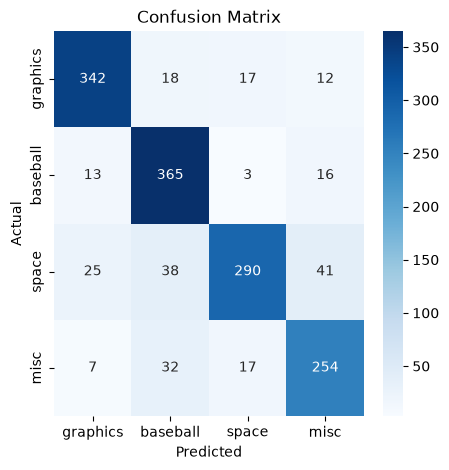

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_test_bow = bow_vectorizer.transform(processed_test_texts)

# Make predictions
predictions_bow = classifier_bow.predict(X_test_bow)
probabilities = classifier_bow.predict_proba(X_test_bow)

# Calculate overall accuracy
overall_accuracy = accuracy_score(test_labels, predictions_bow)
print(f"Overall Test Accuracy: {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")

# Detailed report
print("\nDetailed Classification Report:")
print(classification_report(test_labels, predictions_bow, 
                          target_names=newsgroups_test.target_names))

# Confusion Matrix
cm = confusion_matrix(test_labels, predictions_bow)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[name.split('.')[-1] for name in newsgroups_test.target_names],
            yticklabels=[name.split('.')[-1] for name in newsgroups_test.target_names])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#### TF-IDF

Overall Test Accuracy: 0.864 (86.4%)

Detailed Classification Report:
                    precision    recall  f1-score   support

     comp.graphics       0.89      0.89      0.89       389
rec.sport.baseball       0.85      0.94      0.89       397
         sci.space       0.84      0.84      0.84       394
talk.politics.misc       0.89      0.77      0.82       310

          accuracy                           0.86      1490
         macro avg       0.87      0.86      0.86      1490
      weighted avg       0.87      0.86      0.86      1490


Confusion Matrix:
[[348  15  24   2]
 [ 12 372   3  10]
 [ 23  25 329  17]
 [  7  28  37 238]]


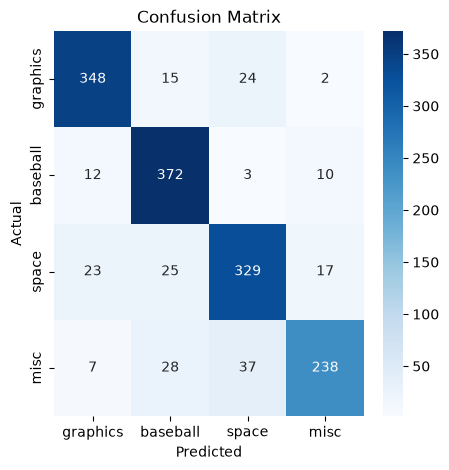

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_test_tfidf = tfidf_vectorizer.transform(processed_test_texts)

# Make predictions
predictions_tfidf = classifier_tfidf.predict(X_test_tfidf)
probabilities = classifier_tfidf.predict_proba(X_test_tfidf)

# Calculate overall accuracy
overall_accuracy = accuracy_score(test_labels, predictions_tfidf)
print(f"Overall Test Accuracy: {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")

# Detailed report
print("\nDetailed Classification Report:")
print(classification_report(test_labels, predictions_tfidf, 
                          target_names=newsgroups_test.target_names))

# Confusion Matrix
cm = confusion_matrix(test_labels, predictions_tfidf)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[name.split('.')[-1] for name in newsgroups_test.target_names],
            yticklabels=[name.split('.')[-1] for name in newsgroups_test.target_names])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#### Printing Results

Bag of Words

In [14]:
# Show results for first 5 articles
for i in range(5):
    actual_category = newsgroups_test.target_names[test_labels[i]]
    predicted_category = newsgroups_test.target_names[predictions_bow[i]]
    confidence = probabilities[i].max()
    
    print(f"Article {i+1}:")
    print(f"Text: {test_texts[i][:100]}...")
    print(f"Actual: {actual_category}")
    print(f"Predicted: {predicted_category} (confidence: {confidence:.3f})")
    print(f"Correct: {'✓' if actual_category == predicted_category else '✗'}")
    print("-" * 50)

Article 1:
Text: I am looking for a means to add FLI and FLC animation creation
to a Windows application.  I was hopi...
Actual: comp.graphics
Predicted: comp.graphics (confidence: 0.898)
Correct: ✓
--------------------------------------------------
Article 2:
Text: I just wanted to point out, that Teflon wasn't from the space program.
It was from the WWII nuclear ...
Actual: sci.space
Predicted: sci.space (confidence: 0.521)
Correct: ✓
--------------------------------------------------
Article 3:
Text: I heard they were posted somewhere, but I can not find them.

Please e-mail location.

Thanks,
	-Jod...
Actual: rec.sport.baseball
Predicted: comp.graphics (confidence: 0.506)
Correct: ✗
--------------------------------------------------
Article 4:
Text: 


	When did the BATF say this? Everything I've seen from the BATF,
	from the official version to th...
Actual: talk.politics.misc
Predicted: talk.politics.misc (confidence: 0.278)
Correct: ✓
--------------------------------------------

TF-IDF

In [15]:
# Show results for first 5 articles
for i in range(5):
    actual_category = newsgroups_test.target_names[test_labels[i]]
    predicted_category = newsgroups_test.target_names[predictions_tfidf[i]]
    confidence = probabilities[i].max()
    
    print(f"Article {i+1}:")
    print(f"Text: {test_texts[i][:100]}...")
    print(f"Actual: {actual_category}")
    print(f"Predicted: {predicted_category} (confidence: {confidence:.3f})")
    print(f"Correct: {'✓' if actual_category == predicted_category else '✗'}")
    print("-" * 50)

Article 1:
Text: I am looking for a means to add FLI and FLC animation creation
to a Windows application.  I was hopi...
Actual: comp.graphics
Predicted: comp.graphics (confidence: 0.898)
Correct: ✓
--------------------------------------------------
Article 2:
Text: I just wanted to point out, that Teflon wasn't from the space program.
It was from the WWII nuclear ...
Actual: sci.space
Predicted: sci.space (confidence: 0.521)
Correct: ✓
--------------------------------------------------
Article 3:
Text: I heard they were posted somewhere, but I can not find them.

Please e-mail location.

Thanks,
	-Jod...
Actual: rec.sport.baseball
Predicted: comp.graphics (confidence: 0.506)
Correct: ✗
--------------------------------------------------
Article 4:
Text: 


	When did the BATF say this? Everything I've seen from the BATF,
	from the official version to th...
Actual: talk.politics.misc
Predicted: rec.sport.baseball (confidence: 0.278)
Correct: ✗
--------------------------------------------

### 6. Predicting Custom Data

Now let's try the trained classifiers on our own custom text, not from the dataset.

In [16]:
def predict_custom_text(custom_texts, feature_extraction, classifier, target_names):
    processed_custom_texts = [preprocess_text(text) for text in custom_texts]
    X_test = feature_extraction.transform(processed_custom_texts)

    # Make predictions
    predictions = classifier.predict(X_test)
    probabilities = classifier.predict_proba(X_test)

    results = []
    for i in range(len(custom_texts)):
        predicted_category = target_names[predictions[i]]
        confidence = probabilities[i].max()
        results.append((predicted_category, confidence))

    return results

# Custom examples, one for each category
custom_texts = [
    "The new graphics card renders 3D images with stunning detail and much faster frame rates.",
    "The pitcher threw a perfect game last night, striking out fourteen batters for the win.",
    "The senator proposed a new bill to reform campaign finance and reduce corruption in government.",
    "NASA's latest rocket successfully launched a satellite into orbit around the earth."
]

bow_results = predict_custom_text(custom_texts, bow_vectorizer, classifier_bow, newsgroups_train.target_names)
tfidf_results = predict_custom_text(custom_texts, tfidf_vectorizer, classifier_tfidf, newsgroups_train.target_names)

for text, (category_bow, confidence_bow), (category_tfidf, confidence_tfidf) in zip(custom_texts, bow_results, tfidf_results):
    print(f"Text: {text}")
    print(f"  Bag of Words -> Predicted: {category_bow} (confidence: {confidence_bow:.3f})")
    print(f"  TF-IDF       -> Predicted: {category_tfidf} (confidence: {confidence_tfidf:.3f})")
    print("-" * 50)

Text: The new graphics card renders 3D images with stunning detail and much faster frame rates.
  Bag of Words -> Predicted: comp.graphics (confidence: 1.000)
  TF-IDF       -> Predicted: comp.graphics (confidence: 0.777)
--------------------------------------------------
Text: The pitcher threw a perfect game last night, striking out fourteen batters for the win.
  Bag of Words -> Predicted: rec.sport.baseball (confidence: 1.000)
  TF-IDF       -> Predicted: rec.sport.baseball (confidence: 0.871)
--------------------------------------------------
Text: The senator proposed a new bill to reform campaign finance and reduce corruption in government.
  Bag of Words -> Predicted: talk.politics.misc (confidence: 1.000)
  TF-IDF       -> Predicted: talk.politics.misc (confidence: 0.591)
--------------------------------------------------
Text: NASA's latest rocket successfully launched a satellite into orbit around the earth.
  Bag of Words -> Predicted: sci.space (confidence: 1.000)
  TF-IDF